# GeraldTech Analytics — On-Time Delivery Deep Dive

This notebook explores the Olist e-commerce dataset with focus on:
1. **Descriptive stats:** Categories, sellers, repeat purchase rate
2. **Delay analysis:** Geographic patterns, freight, payment, time, size, problematic sellers
3. **Operational metrics:** Carrier handoff time, delivery variance
4. **Customer impact:** Review scores vs delays

In [135]:
import sys

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_dataset

data_dir = Path('../data')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 50)

## 1. Load Data

In [136]:
orders = load_dataset("orders", data_dir)
order_items = load_dataset("order_items", data_dir)
products = load_dataset("products", data_dir)
customers = load_dataset("customers", data_dir)
payments = load_dataset("payments", data_dir)
sellers = load_dataset("sellers", data_dir)
geolocation = load_dataset("geolocation", data_dir)


# Parse dates
date_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date', 
             'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print(f"Orders: {len(orders):,}")
print(f"Order status distribution:\n{orders['order_status'].value_counts()}")

Orders: 99,441
Order status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


## 2. Descriptive Statistics

### 2.1 Top Product Categories by Orders and GMV

In [137]:
# Merge items with products to get categories
items_products = order_items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')

# GMV = price + freight per item
items_products['gmv'] = items_products['price'] + items_products['freight_value']

category_stats = items_products.groupby('product_category_name').agg(
    order_count=('order_id', 'nunique'),
    item_count=('order_item_id', 'count'),
    gmv=('gmv', 'sum')
).sort_values('gmv', ascending=False).head(15)

category_stats.head(10)

,order_count,item_count,gmv
product_category_name,,,
beleza_saude,8836,9670,1441248.07
relogios_presentes,5624,5991,1305541.61
cama_mesa_banho,9417,11115,1241681.72
esporte_lazer,7720,8641,1156656.48
informatica_acessorios,6689,7827,1059272.40
moveis_decoracao,6449,8334,902511.79
utilidades_domesticas,5884,6964,778397.77
cool_stuff,3632,3796,719329.95
automotivo,3897,4235,685384.32


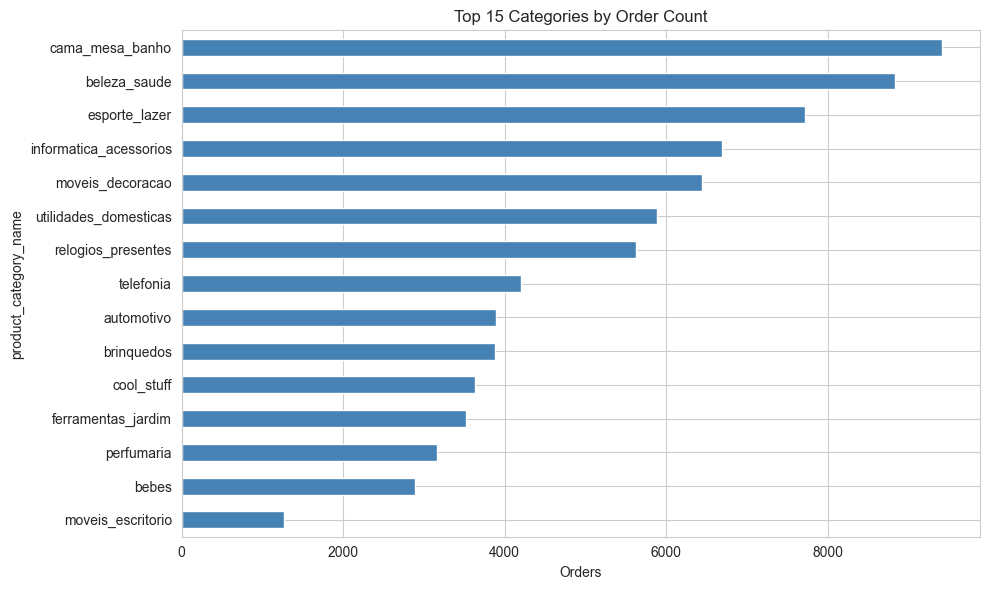

In [138]:
import os
os.makedirs('figs', exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6))
category_stats.sort_values('order_count', ascending=False)['order_count'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 Categories by Order Count')
ax.set_xlabel('Orders')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figs/top_categories_orders.png', dpi=150, bbox_inches='tight')
plt.show()

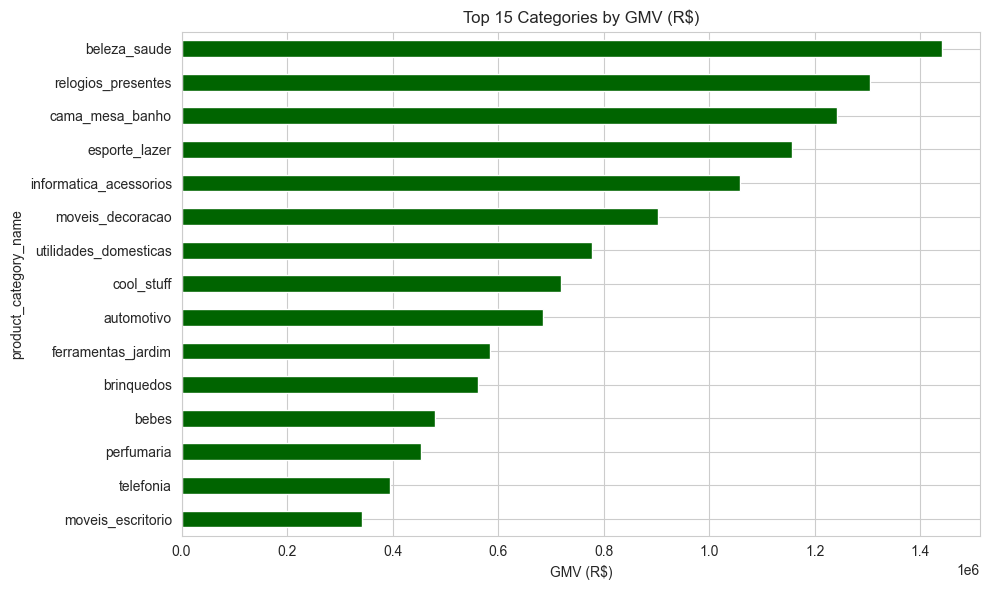

In [139]:
fig, ax = plt.subplots(figsize=(10, 6))
category_stats['gmv'].plot(kind='barh', ax=ax, color='darkgreen')
ax.set_title('Top 15 Categories by GMV (R$)')
ax.set_xlabel('GMV (R$)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figs/top_categories_gmv.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Top Sellers

In [140]:
seller_stats = order_items.groupby('seller_id').agg(
    order_count=('order_id', 'nunique'),
    item_count=('order_item_id', 'count'),
    total_revenue=('price', 'sum'),
    total_freight=('freight_value', 'sum')
).sort_values('total_revenue', ascending=False)

seller_stats['gmv'] = seller_stats['total_revenue'] + seller_stats['total_freight']

print(f"Total sellers: {len(seller_stats):,}")
print(f"\nTop 10 sellers by GMV:")
seller_stats.head(10)

Total sellers: 3,095

Top 10 sellers by GMV:


,order_count,item_count,total_revenue,total_freight,gmv
seller_id,,,,,
4869f7a5dfa277a7dca6462dcf3b52b2,1132,1156,229472.63,20168.07,249640.70
53243585a1d6dc2643021fd1853d8905,358,410,222776.05,13080.63,235856.68
4a3ca9315b744ce9f8e9374361493884,1806,1987,200472.92,35067.04,235539.96
fa1c13f2614d7b5c4749cbc52fecda94,585,586,194042.03,10042.70,204084.73
7c67e1448b00f6e969d365cea6b010ab,982,1364,187923.89,51612.55,239536.44
7e93a43ef30c4f03f38b393420bc753a,336,340,176431.87,6322.18,182754.05
da8622b14eb17ae2831f4ac5b9dab84a,1314,1551,160236.57,24955.75,185192.32
7a67c85e85bb2ce8582c35f2203ad736,1160,1171,141745.53,20902.85,162648.38
1025f0e2d44d7041d6cf58b6550e0bfa,915,1428,138968.55,33892.14,172860.69


### 2.3 Repeat Purchase Rate

In [141]:
customer_orders = orders.groupby('customer_id').agg(
    order_count=('order_id', 'count'),
    first_order=('order_purchase_timestamp', 'min'),
    last_order=('order_purchase_timestamp', 'max')
)

repeat_customers = (customer_orders['order_count'] > 1).sum()
total_customers = len(customer_orders)
repeat_rate = repeat_customers / total_customers

print(f"Total unique customers: {total_customers:,}")
print(f"Repeat customers (>1 order): {repeat_customers:,}")
print(f"Repeat purchase rate: {repeat_rate:.2%}")

# Average time between orders for repeat customers
repeat_df = customer_orders[customer_orders['order_count'] > 1].copy()
repeat_df['days_between'] = (repeat_df['last_order'] - repeat_df['first_order']).dt.days
avg_days_between = repeat_df['days_between'].mean()
print(f"Average days between first and last order (repeat customers): {avg_days_between:.1f} days")

Total unique customers: 99,441
Repeat customers (>1 order): 0
Repeat purchase rate: 0.00%
Average days between first and last order (repeat customers): nan days


### 2.4 Order Conversion & Review Distribution

In [142]:
# Order status distribution
status_counts = orders['order_status'].value_counts()
delivered_rate = status_counts.get('delivered', 0) / len(orders)

print(f"Delivered orders: {delivered_rate:.2%}")
print(f"\nOrder status breakdown:")
print(status_counts)

Delivered orders: 97.02%

Order status breakdown:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


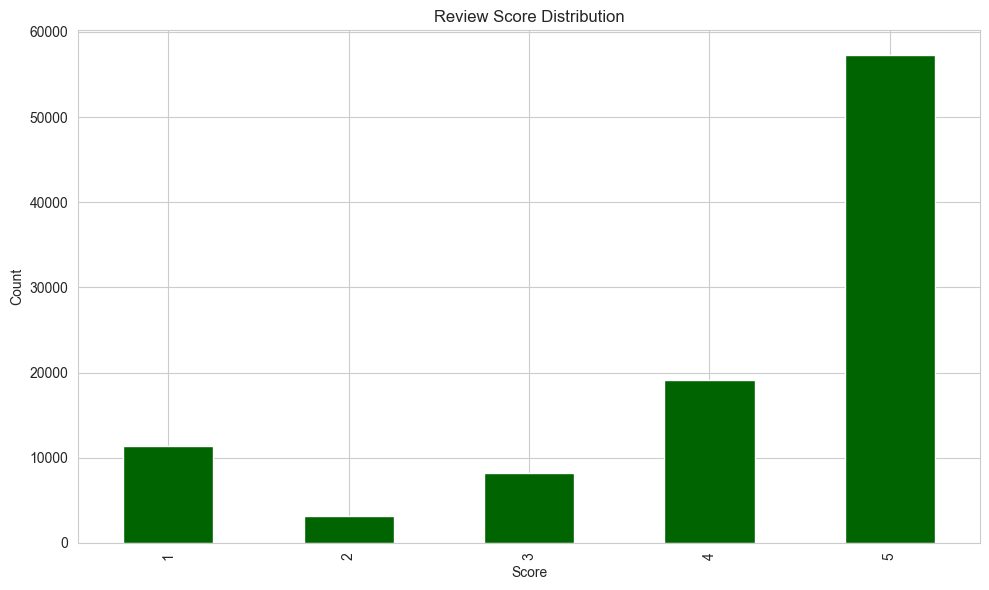

Average review score: 4.09


In [143]:
reviews = load_dataset('reviews', data_dir)

fig, ax = plt.subplots(figsize=(10, 6))
reviews['review_score'].value_counts().sort_index().plot(kind='bar', ax=ax, color='darkgreen')
ax.set_title('Review Score Distribution')
ax.set_xlabel('Score')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('figs/review_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average review score: {reviews['review_score'].mean():.2f}")

---
## 3. Delay Analysis

Focus: Understanding patterns in delayed orders (delivered after estimated date)

In [144]:
# Filter to delivered orders with valid dates
delivered = orders[orders['order_status'] == 'delivered'].copy()
delivered = delivered.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date'])

# Create delay flag and delay days
delivered['is_late'] = (delivered['order_delivered_customer_date'] > delivered['order_estimated_delivery_date']).astype(int)
delivered['delay_days'] = (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']).dt.days

on_time_rate = 1 - delivered['is_late'].mean()
print(f"Delivered orders: {len(delivered):,}")
print(f"On-time delivery rate: {on_time_rate:.2%}")
print(f"Late deliveries: {delivered['is_late'].sum():,} ({delivered['is_late'].mean():.2%})")
print(f"\nDelay stats (days, positive = late):")
print(delivered['delay_days'].describe())

Delivered orders: 96,470
On-time delivery rate: 91.89%
Late deliveries: 7,826 (8.11%)

Delay stats (days, positive = late):
count    96470.000000
mean       -11.875889
std         10.182105
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delay_days, dtype: float64


### 3.1 Delay Rate by State

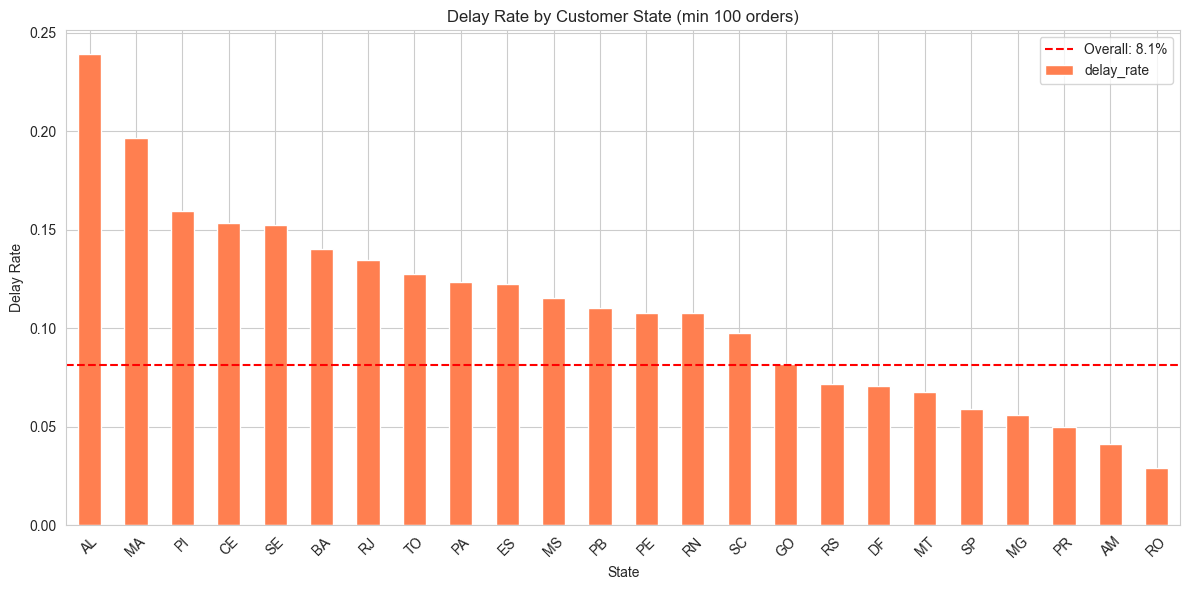

Top 5 states with highest delay rate:


,total_orders,late_orders,avg_delay_days,delay_rate
customer_state,,,,
AL,397,95,-8.707809,0.239295
MA,717,141,-9.571827,0.196653
PI,476,76,-11.306723,0.159664
CE,1279,196,-10.804535,0.153245
SE,335,51,-10.020896,0.152239


In [145]:
# Merge with customers to get state
delivered_geo = delivered.merge(customers[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='left')

state_delays = delivered_geo.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum'),
    avg_delay_days=('delay_days', 'mean')
)
state_delays['delay_rate'] = state_delays['late_orders'] / state_delays['total_orders']
state_delays = state_delays.sort_values('delay_rate', ascending=False)

# Filter to states with at least 100 orders for significance
state_delays_sig = state_delays[state_delays['total_orders'] >= 100]

fig, ax = plt.subplots(figsize=(12, 6))
state_delays_sig['delay_rate'].plot(kind='bar', ax=ax, color='coral')
ax.axhline(y=delivered['is_late'].mean(), color='red', linestyle='--', label=f'Overall: {delivered["is_late"].mean():.1%}')
ax.set_title('Delay Rate by Customer State (min 100 orders)')
ax.set_xlabel('State')
ax.set_ylabel('Delay Rate')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figs/delay_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 states with highest delay rate:")
state_delays_sig.head()

### 3.2 Delay vs Freight Price

In [146]:
# Merge with order items for freight
items_agg = order_items.groupby('order_id').agg(
    freight_value=('freight_value', 'sum'),
    item_count=('order_item_id', 'count'),
    total_price=('price', 'sum')
).reset_index()

delivered_freight = delivered.merge(items_agg, on='order_id', how='left')

# Compare freight for late vs on-time
late_freight = delivered_freight[delivered_freight['is_late'] == 1]['freight_value']
ontime_freight = delivered_freight[delivered_freight['is_late'] == 0]['freight_value']

print(f"Average freight - Late orders: R${late_freight.mean():.2f}")
print(f"Average freight - On-time orders: R${ontime_freight.mean():.2f}")
print(f"Difference: R${late_freight.mean() - ontime_freight.mean():.2f}")

Average freight - Late orders: R$24.62
Average freight - On-time orders: R$22.62
Difference: R$2.00


### 3.3 Delay vs Payment Type

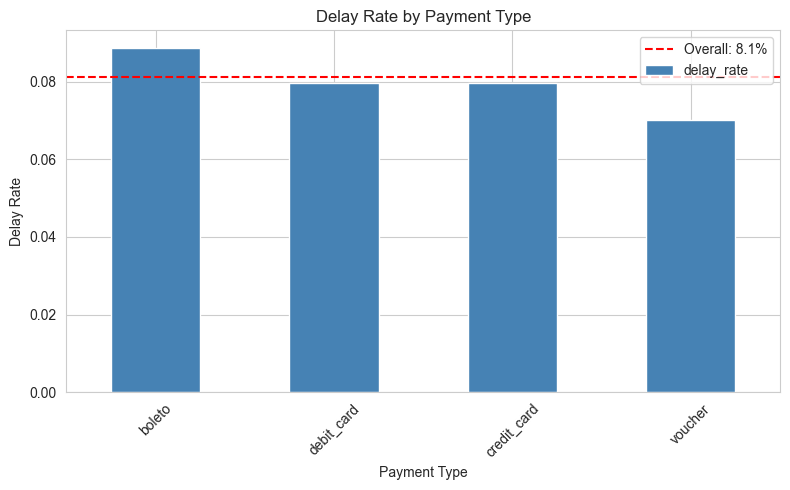

,total_orders,late_orders,delay_rate
payment_type,,,
boleto,19191,1704,0.088792
debit_card,1483,118,0.079568
credit_card,72818,5794,0.079568
voucher,2977,209,0.070205


In [147]:
# Get primary payment type per order
payment_primary = payments.sort_values('payment_value', ascending=False).groupby('order_id').first().reset_index()

delivered_payment = delivered.merge(payment_primary[['order_id', 'payment_type', 'payment_value']], on='order_id', how='left')

payment_delays = delivered_payment.groupby('payment_type').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum')
)
payment_delays['delay_rate'] = payment_delays['late_orders'] / payment_delays['total_orders']
payment_delays = payment_delays.sort_values('delay_rate', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
payment_delays['delay_rate'].plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(y=delivered['is_late'].mean(), color='red', linestyle='--', label=f'Overall: {delivered["is_late"].mean():.1%}')
ax.set_title('Delay Rate by Payment Type')
ax.set_xlabel('Payment Type')
ax.set_ylabel('Delay Rate')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figs/delay_by_payment.png', dpi=150, bbox_inches='tight')
plt.show()

payment_delays

### 3.4 Delay vs Time Patterns

In [148]:
delivered['order_month'] = delivered['order_purchase_timestamp'].dt.month
delivered['order_dayofweek'] = delivered['order_purchase_timestamp'].dt.dayofweek
delivered['order_hour'] = delivered['order_purchase_timestamp'].dt.hour

month_delays = delivered.groupby('order_month')['is_late'].mean()
dow_delays = delivered.groupby('order_dayofweek')['is_late'].mean()
hour_delays = delivered.groupby('order_hour')['is_late'].mean()

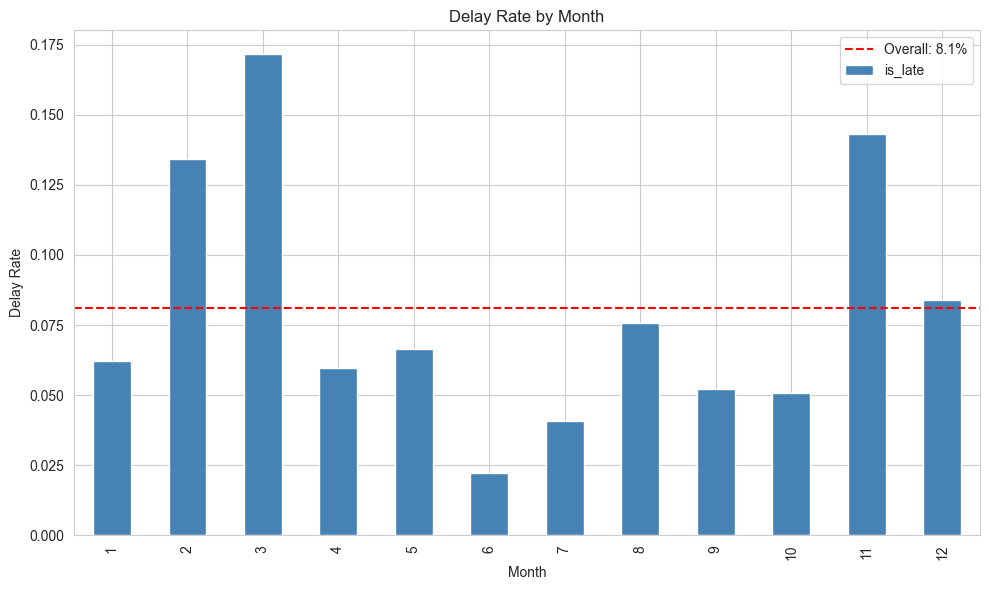

In [149]:
fig, ax = plt.subplots(figsize=(10, 6))
month_delays.plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(y=delivered['is_late'].mean(), color='red', linestyle='--', label=f'Overall: {delivered["is_late"].mean():.1%}')
ax.set_title('Delay Rate by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Delay Rate')
ax.legend()
plt.tight_layout()
plt.savefig('figs/delay_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

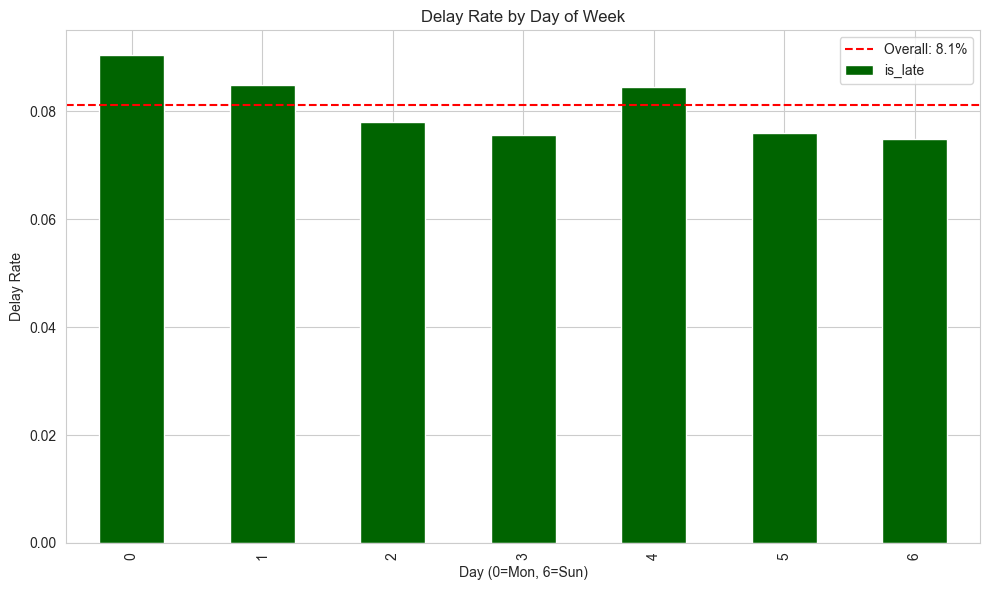

In [150]:
fig, ax = plt.subplots(figsize=(10, 6))
dow_delays.plot(kind='bar', ax=ax, color='darkgreen')
ax.axhline(y=delivered['is_late'].mean(), color='red', linestyle='--', label=f'Overall: {delivered["is_late"].mean():.1%}')
ax.set_title('Delay Rate by Day of Week')
ax.set_xlabel('Day (0=Mon, 6=Sun)')
ax.set_ylabel('Delay Rate')
ax.legend()
plt.tight_layout()
plt.savefig('figs/delay_by_dayofweek.png', dpi=150, bbox_inches='tight')
plt.show()

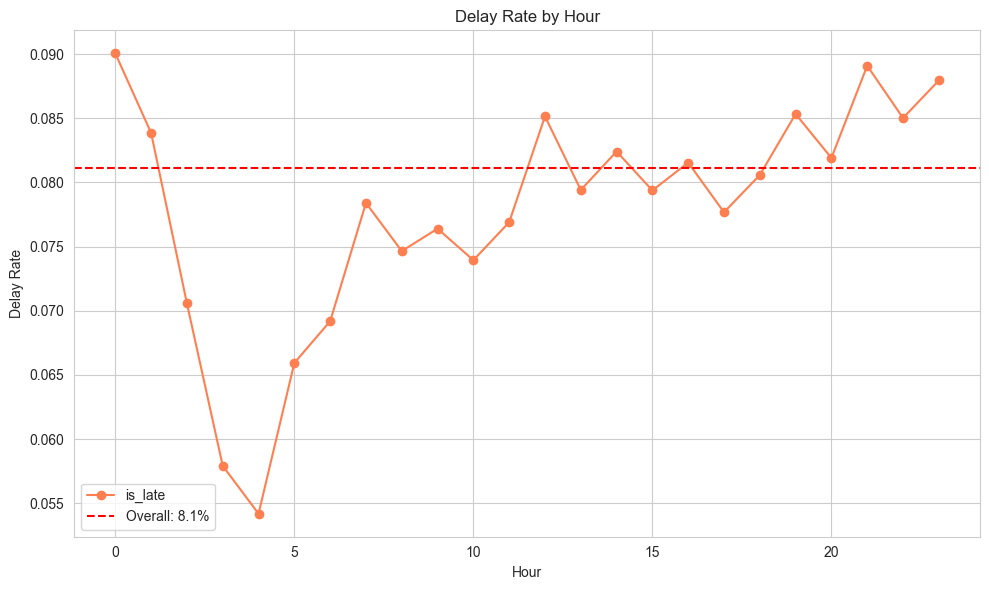

In [151]:
fig, ax = plt.subplots(figsize=(10, 6))
hour_delays.plot(kind='line', ax=ax, color='coral', marker='o')
ax.axhline(y=delivered['is_late'].mean(), color='red', linestyle='--', label=f'Overall: {delivered["is_late"].mean():.1%}')
ax.set_title('Delay Rate by Hour')
ax.set_xlabel('Hour')
ax.set_ylabel('Delay Rate')
ax.legend()
plt.tight_layout()
plt.savefig('figs/delay_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Delay vs Product Size and Weight

Average weight - Late orders: 2652g
Average weight - On-time orders: 2363g
Difference: 289g


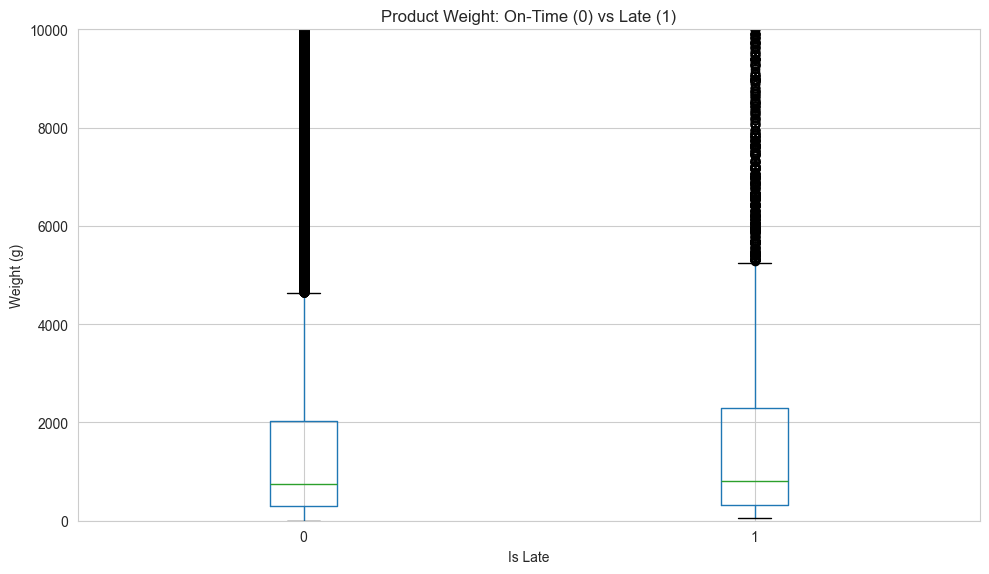

In [152]:
# Merge with products
items_prods = order_items.merge(products, on='product_id', how='left')

# Calculate volume per item then aggregate
items_prods['volume_cm3'] = (items_prods['product_length_cm'] * 
                              items_prods['product_height_cm'] * 
                              items_prods['product_width_cm'])

prods_agg = items_prods.groupby('order_id').agg(
    weight_g=('product_weight_g', 'sum'),
    total_volume=('volume_cm3', 'sum')
).reset_index()

delivered_size = delivered.merge(prods_agg, on='order_id', how='left')

# Compare weight for late vs on-time
late_weight = delivered_size[delivered_size['is_late'] == 1]['weight_g'].dropna()
ontime_weight = delivered_size[delivered_size['is_late'] == 0]['weight_g'].dropna()

print(f"Average weight - Late orders: {late_weight.mean():.0f}g")
print(f"Average weight - On-time orders: {ontime_weight.mean():.0f}g")
print(f"Difference: {late_weight.mean() - ontime_weight.mean():.0f}g")

fig, ax = plt.subplots(figsize=(10, 6))
delivered_size.boxplot(column='weight_g', by='is_late', ax=ax)
ax.set_title('Product Weight: On-Time (0) vs Late (1)')
ax.set_xlabel('Is Late')
ax.set_ylabel('Weight (g)')
plt.suptitle('')
plt.ylim(0, 10000)
plt.tight_layout()
plt.savefig('figs/delay_vs_weight.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Problematic Sellers (High Delay Rate)

In [153]:
# Get seller per order (first if multiple)
order_seller = order_items.groupby('order_id')['seller_id'].first().reset_index()
delivered_seller = delivered.merge(order_seller, on='order_id', how='left')

seller_delays = delivered_seller.groupby('seller_id').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum'),
    avg_delay_days=('delay_days', 'mean')
)
seller_delays['delay_rate'] = seller_delays['late_orders'] / seller_delays['total_orders']

# Filter to sellers with at least 50 orders
seller_delays_sig = seller_delays[seller_delays['total_orders'] >= 50].sort_values('delay_rate', ascending=False)

print(f"Sellers with 50+ orders: {len(seller_delays_sig)}")
print(f"\nTop 10 sellers with highest delay rate:")
seller_delays_sig.head(10)

Sellers with 50+ orders: 419

Top 10 sellers with highest delay rate:


,total_orders,late_orders,avg_delay_days,delay_rate
seller_id,,,,
54965bbe3e4f07ae045b90b0b8541f52,72,22,-3.333333,0.305556
a49928bcdf77c55c6d6e05e09a9b4ca5,94,25,-4.244681,0.265957
beadbee30901a7f61d031b6b686095ad,63,16,-9.285714,0.253968
06a2c3af7b3aee5d69171b0e14f0ee87,388,90,-11.324742,0.231959
6039e27294dc75811c0d8a39069f52c0,62,14,-7.048387,0.225806
cac4c8e7b1ca6252d8f20b2fc1a2e4af,71,16,-6.478873,0.225352
1ca7077d890b907f89be8c954a02686a,108,24,-6.666667,0.222222
712e6ed8aa4aa1fa65dab41fed5737e4,77,17,-9.116883,0.220779
ea566164622c6b439516ab18062c42cd,50,11,-8.100000,0.220000


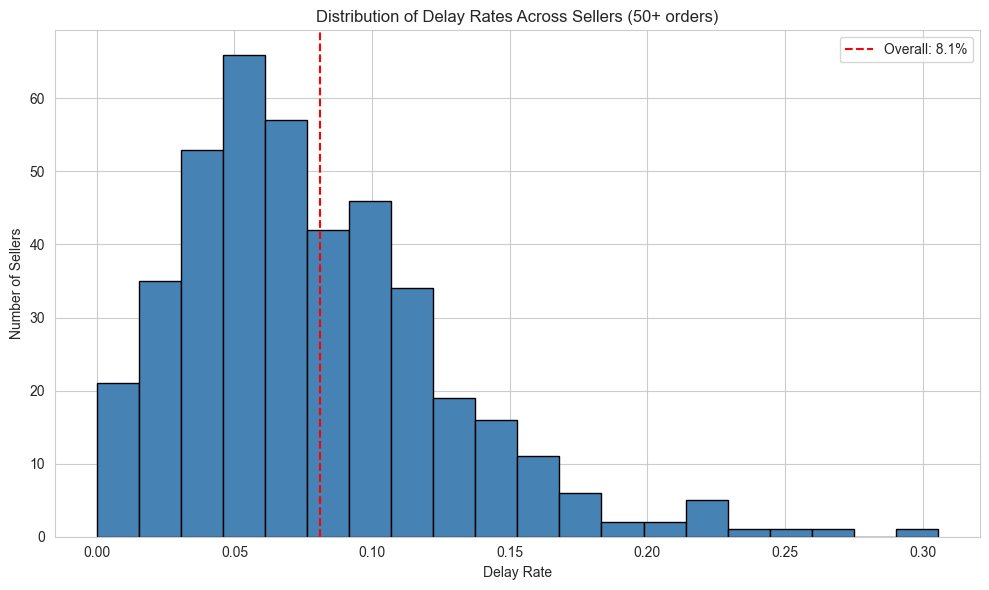


Problematic sellers (delay rate > 16.2%): 20
These sellers account for 2,432 orders


In [154]:
# Seller delay rate distribution
fig, ax = plt.subplots(figsize=(10, 6))
seller_delays_sig['delay_rate'].hist(bins=20, ax=ax, color='steelblue', edgecolor='black')
ax.axvline(x=delivered['is_late'].mean(), color='red', linestyle='--', label=f'Overall: {delivered["is_late"].mean():.1%}')
ax.set_title('Distribution of Delay Rates Across Sellers (50+ orders)')
ax.set_xlabel('Delay Rate')
ax.set_ylabel('Number of Sellers')
ax.legend()
plt.tight_layout()
plt.savefig('figs/seller_delay_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Problematic sellers (delay rate > 2x average)
threshold = delivered['is_late'].mean() * 2
problematic = seller_delays_sig[seller_delays_sig['delay_rate'] > threshold]
print(f"\nProblematic sellers (delay rate > {threshold:.1%}): {len(problematic)}")
print(f"These sellers account for {problematic['total_orders'].sum():,} orders")

---
## 4. Operational Metrics

### 4.1 Carrier Handoff Time

Carrier handoff time stats (hours):
count    95105.000000
mean        68.481390
std         83.652306
min          0.004167
25%         21.613333
50%         44.377222
75%         86.843611
max       3018.301667
Name: handoff_hours, dtype: float64

Average handoff time - Late orders: 128.4 hours
Average handoff time - On-time orders: 63.1 hours


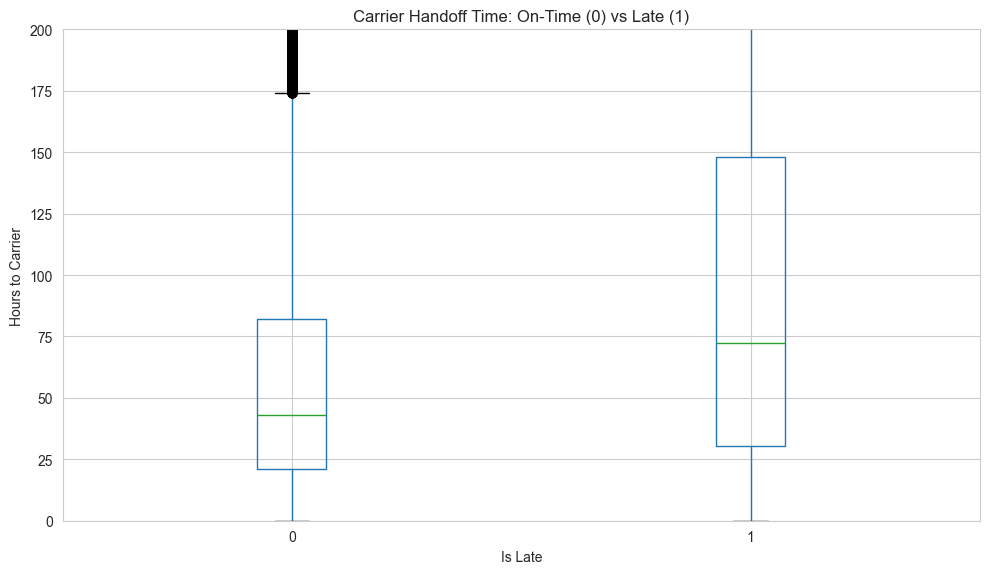

In [155]:
# Time from approval to carrier handoff
delivered_ops = delivered.dropna(subset=['order_approved_at', 'order_delivered_carrier_date']).copy()
delivered_ops['handoff_hours'] = (delivered_ops['order_delivered_carrier_date'] - delivered_ops['order_approved_at']).dt.total_seconds() / 3600

# Filter out negative values (data issues)
delivered_ops = delivered_ops[delivered_ops['handoff_hours'] >= 0]

print(f"Carrier handoff time stats (hours):")
print(delivered_ops['handoff_hours'].describe())

# Compare handoff time for late vs on-time
late_handoff = delivered_ops[delivered_ops['is_late'] == 1]['handoff_hours']
ontime_handoff = delivered_ops[delivered_ops['is_late'] == 0]['handoff_hours']

print(f"\nAverage handoff time - Late orders: {late_handoff.mean():.1f} hours")
print(f"Average handoff time - On-time orders: {ontime_handoff.mean():.1f} hours")

fig, ax = plt.subplots(figsize=(10, 6))
delivered_ops.boxplot(column='handoff_hours', by='is_late', ax=ax)
ax.set_title('Carrier Handoff Time: On-Time (0) vs Late (1)')
ax.set_xlabel('Is Late')
ax.set_ylabel('Hours to Carrier')
plt.suptitle('')
plt.ylim(0, 200)
plt.tight_layout()
plt.savefig('figs/carrier_handoff.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Delivery Time Variance (Actual vs Estimated)

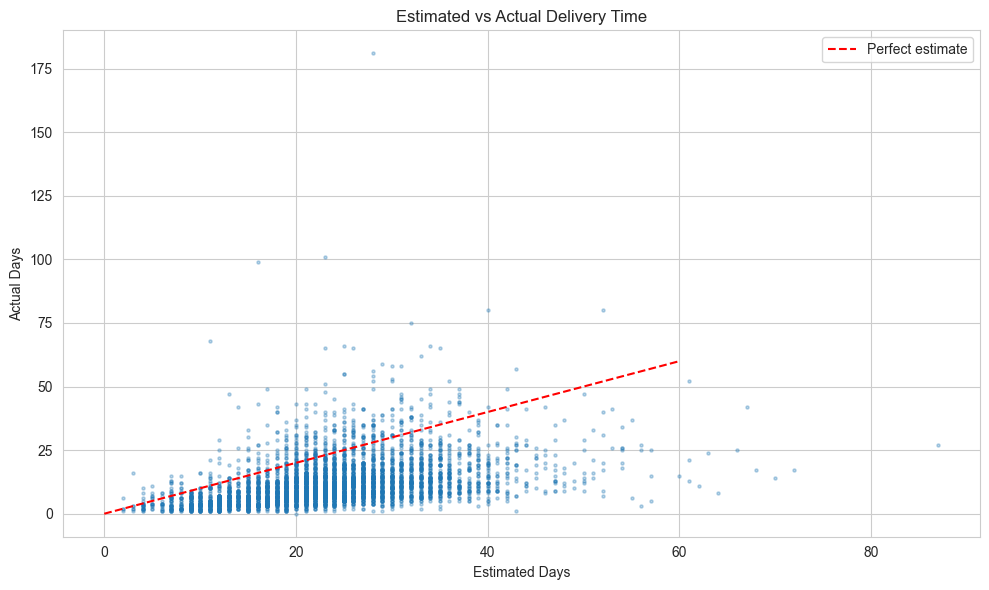

In [156]:
# Calculate actual vs estimated delivery days
delivered['actual_days'] = (delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']).dt.days
delivered['estimated_days'] = (delivered['order_estimated_delivery_date'] - delivered['order_purchase_timestamp']).dt.days

fig, ax = plt.subplots(figsize=(10, 6))
sample = delivered.sample(min(5000, len(delivered)), random_state=42)
ax.scatter(sample['estimated_days'], sample['actual_days'], alpha=0.3, s=5)
ax.plot([0, 60], [0, 60], 'r--', label='Perfect estimate')
ax.set_title('Estimated vs Actual Delivery Time')
ax.set_xlabel('Estimated Days')
ax.set_ylabel('Actual Days')
ax.legend()
plt.tight_layout()
plt.savefig('figs/delivery_variance_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Review Score vs Delay (Customer Impact)

In [157]:
# Merge delivered orders with reviews
delivered_reviews = delivered.merge(reviews[['order_id', 'review_score']], on='order_id', how='inner')

print(f"Orders with reviews: {len(delivered_reviews):,}")

# Average score by delay status
late_score = delivered_reviews[delivered_reviews['is_late'] == 1]['review_score'].mean()
ontime_score = delivered_reviews[delivered_reviews['is_late'] == 0]['review_score'].mean()

print(f"\nAverage review score - Late orders: {late_score:.2f}")
print(f"Average review score - On-time orders: {ontime_score:.2f}")
print(f"Score difference: {ontime_score - late_score:.2f} stars")

Orders with reviews: 96,353

Average review score - Late orders: 2.57
Average review score - On-time orders: 4.29
Score difference: 1.73 stars


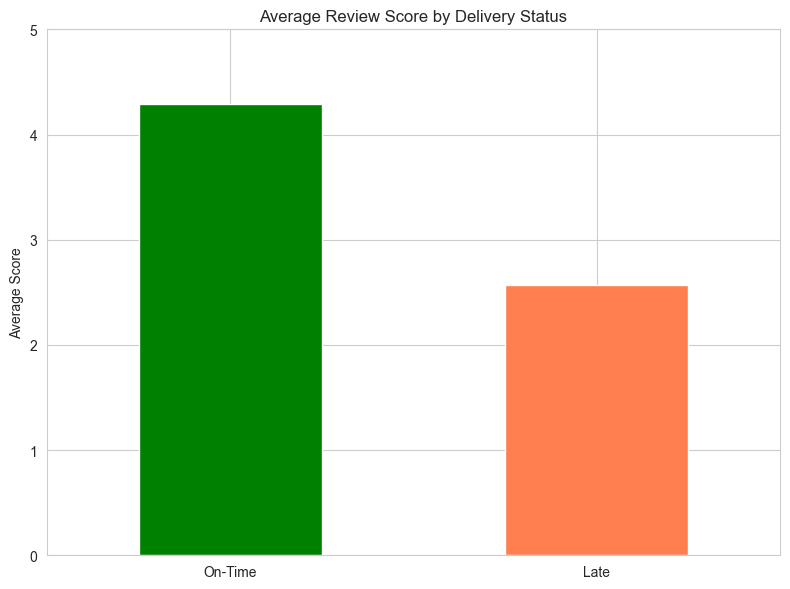

In [158]:
fig, ax = plt.subplots(figsize=(8, 6))
pd.Series({'On-Time': ontime_score, 'Late': late_score}).plot(kind='bar', ax=ax, color=['green', 'coral'])
ax.set_title('Average Review Score by Delivery Status')
ax.set_ylabel('Average Score')
ax.set_ylim(0, 5)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('figs/review_avg_by_delay.png', dpi=150, bbox_inches='tight')
plt.show()

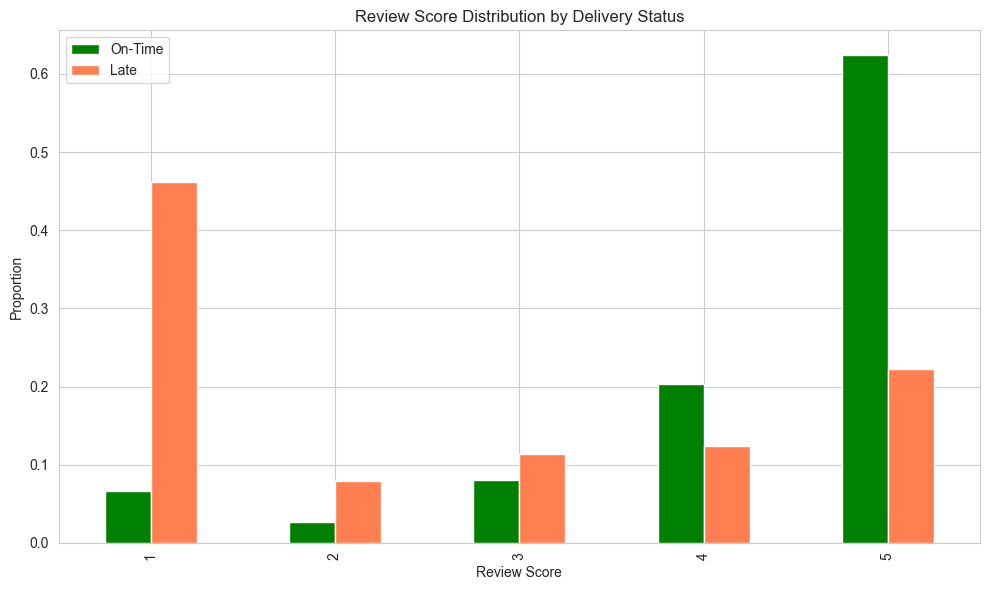

In [159]:
fig, ax = plt.subplots(figsize=(10, 6))
score_dist = delivered_reviews.groupby(['is_late', 'review_score']).size().unstack(fill_value=0)
score_dist_pct = score_dist.div(score_dist.sum(axis=1), axis=0)
score_dist_pct.T.plot(kind='bar', ax=ax, color=['green', 'coral'])
ax.set_title('Review Score Distribution by Delivery Status')
ax.set_xlabel('Review Score')
ax.set_ylabel('Proportion')
ax.legend(['On-Time', 'Late'])
plt.tight_layout()
plt.savefig('figs/review_dist_by_delay.png', dpi=150, bbox_inches='tight')
plt.show()